In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.nn.utils.rnn import pad_sequence
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding
)
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
 
os.makedirs('../data/images/bert_lora', exist_ok=True)
os.makedirs('../models/bert_lora', exist_ok=True)

In [14]:
# =============================================================================
# WHAT IS LoRA?
# =============================================================================
# LoRA (Low-Rank Adaptation, Hu et al. 2021) is a Parameter-Efficient Fine-
# Tuning (PEFT) technique. Instead of updating all ~110M parameters of BERT,
# LoRA freezes the original weights and injects small trainable low-rank
# matrices into the attention layers.
#
# For each attention weight matrix W (shape d x d), LoRA adds:
#   W' = W + BA
# where B (d x r) and A (r x d) are small matrices with rank r << d.
#
# Why this matters:
#   - Full BERT fine-tuning: ~110M trainable parameters
#   - BERT + LoRA (r=8):     ~300K trainable parameters (~0.3% of total)
#   - Training is faster, uses less memory, and generalizes better on
#     small datasets by reducing overfitting risk.
#
# This is the "Serendipity" contribution of this project — applying an
# advanced PEFT technique that matches the F1 of full fine-tuning at a
# fraction of the computational cost.
#
# Source: inspired by Project 5 (hsiehbocheng), reimplemented with
# bert-base-uncased for consistency with our bert.ipynb (Step 3).
 
# =============================================================================
# CONFIGURATION
# =============================================================================
 
# BERTweet: RoBERTa pre-trained on 850M English tweets (Nguyen et al. 2020)
# Unlike bert-base-uncased (trained on Wikipedia + BooksCorpus), BERTweet
# was pre-trained specifically on Twitter data — same domain as this task.
# This gives better tokenization of Twitter-specific language (hashtags,
# mentions, abbreviations, informal spelling).
# Model: https://huggingface.co/vinai/bertweet-base
MODEL_CHECKPOINT = 'vinai/bertweet-base'
MAX_LENGTH              = 128
BATCH_SIZE              = 16
LEARNING_RATE           = 2e-4      # LoRA typically uses higher lr than full fine-tuning
NUM_EPOCHS              = 3
VAL_SIZE                = 0.1
SEED                    = 42
WARMUP_STEPS            = 0.1       # warm up for first 100 steps
LABEL_SMOOTHING_FACTOR  = 0.1       # helps prevent overconfidence and overfitting
 
# LoRA hyperparameters
LORA_R           = 8    # rank of the low-rank matrices — controls capacity
LORA_ALPHA       = 16   # scaling factor: effective lr = alpha/r * lr
LORA_DROPOUT     = 0.1  # dropout on LoRA layers
 
torch.manual_seed(SEED)
np.random.seed(SEED)

In [15]:
# =============================================================================
# LOAD DATA
# =============================================================================

df_full = pd.read_csv('../data/augmented_train.csv')
df_test = pd.read_csv('../data/test_cleaned.csv')

# Separate original rows from augmented rows
# Original rows: id <= original_max_id
# Augmented rows (back-translation EN→HI→EN): id > original_max_id
original_max_id = df_full['id'].max() // 2
df_orig      = df_full[df_full['id'] <= original_max_id].copy()
df_augmented = df_full[df_full['id'] >  original_max_id].copy()

print(f"Original rows  : {len(df_orig)}")
print(f"Augmented rows : {len(df_augmented)}")
print(f"Test rows      : {len(df_test)}")
print(f"\nLabel distribution (original):")
print(df_orig['target_relabeled'].value_counts(normalize=True).round(3))

# =============================================================================
# TRAIN / VALIDATION SPLIT
# =============================================================================
# IMPORTANT: split is done on ORIGINAL rows only.
# This ensures validation contains only unseen original tweets — no
# back-translations of training samples, which would inflate Val F1.
# Augmented rows are then added exclusively to the training set.

df_work_orig = df_orig[['text_cleaned', 'target_relabeled']].dropna()
df_work_orig = df_work_orig.rename(columns={'target_relabeled': 'label'})
df_work_orig = df_work_orig.drop_duplicates(subset='text_cleaned')

train_orig_df, val_df = train_test_split(
    df_work_orig,
    test_size=VAL_SIZE,
    stratify=df_work_orig['label'],
    random_state=SEED
)

# Prepare augmented rows and add them to training only
df_work_aug = df_augmented[['text_cleaned', 'target_relabeled']].dropna()
df_work_aug = df_work_aug.rename(columns={'target_relabeled': 'label'})
df_work_aug = df_work_aug.drop_duplicates(subset='text_cleaned')

# Final training set = original train split + all augmented rows
train_df = pd.concat([train_orig_df, df_work_aug], ignore_index=True)

overlap = len(set(train_orig_df['text_cleaned']) & set(val_df['text_cleaned']))
print(f"\nOriginal train size  : {len(train_orig_df)}")
print(f"Augmented rows added : {len(df_work_aug)}")
print(f"Final train size     : {len(train_df)}")
print(f"Val size             : {len(val_df)}  ← only original rows")
print(f"Overlap train/val    : {overlap}  ← must be 0")

Original rows  : 7613
Augmented rows : 7608
Test rows      : 3263

Label distribution (original):
target_relabeled
0    0.572
1    0.428
Name: proportion, dtype: float64

Original train size  : 6286
Augmented rows added : 7050
Final train size     : 13336
Val size             : 699  ← only original rows
Overlap train/val    : 0  ← must be 0


In [16]:
# =============================================================================
# TOKENIZATION
# =============================================================================

tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT, use_fast=False, normalization=True)
 
def tokenize(example):
    return tokenizer(
        example['text_cleaned'],
        truncation=True,
        max_length=MAX_LENGTH
    )
 
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
val_dataset   = Dataset.from_pandas(val_df.reset_index(drop=True))
test_work     = df_test[['text_cleaned']].copy()
test_dataset  = Dataset.from_pandas(test_work.reset_index(drop=True))
 
train_dataset = train_dataset.map(tokenize, batched=True)
val_dataset   = val_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)
 
print("Tokenization complete.")

emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


Map:   0%|          | 0/13336 [00:00<?, ? examples/s]

Map:   0%|          | 0/699 [00:00<?, ? examples/s]

Map:   0%|          | 0/3263 [00:00<?, ? examples/s]

Tokenization complete.


In [17]:
# =============================================================================
# MODEL + LoRA
# =============================================================================
# Step 1: Load bert-base-uncased with a classification head (same as bert.ipynb)
# Step 2: Wrap it with LoRA using the PEFT library
#
# LoraConfig parameters:
#   task_type     : SEQ_CLS = sequence classification
#   r             : rank of the decomposition matrices (8 is a standard default)
#   lora_alpha    : scaling — higher alpha = stronger LoRA signal
#   target_modules: which weight matrices to apply LoRA to.
#                   "query" and "value" are the standard choice from the paper.
#   lora_dropout  : regularization on LoRA weights
#   bias          : "none" = do not train any bias terms
 
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CHECKPOINT,
    num_labels=2,
    ignore_mismatched_sizes=True
)
 
lora_config = LoraConfig(
    task_type      = TaskType.SEQ_CLS,
    r              = LORA_R,
    lora_alpha     = LORA_ALPHA,
    target_modules = ['query', 'value'],
    lora_dropout   = LORA_DROPOUT,
    bias           = 'none'
)
 
model = get_peft_model(base_model, lora_config)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initi

In [18]:
# =============================================================================
# TRAINABLE PARAMETERS COMPARISON
# =============================================================================
# This is the key result for Serendipity — show how few parameters LoRA trains.
 
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
 
print(f"\n{'='*50}")
print(f"  PARAMETER EFFICIENCY")
print(f"{'='*50}")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")
print(f"  Trainable %          : {100 * trainable_params / total_params:.2f}%")
print(f"{'='*50}")
print(f"\n  Full BERT fine-tuning trains ~125M parameters (100%)")
print(f"  BERT + LoRA trains only {trainable_params:,} parameters ({100 * trainable_params / total_params:.2f}%)")


  PARAMETER EFFICIENCY
  Total parameters     : 135,788,548
  Trainable parameters : 887,042
  Trainable %          : 0.65%

  Full BERT fine-tuning trains ~125M parameters (100%)
  BERT + LoRA trains only 887,042 parameters (0.65%)


In [19]:
# =============================================================================
# TRAINING
# =============================================================================
 
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {'f1': f1_score(labels, preds)}
 
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
 
training_args = TrainingArguments(
    output_dir                  = '../models/bert_lora',
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    learning_rate               = LEARNING_RATE,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    num_train_epochs            = NUM_EPOCHS,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'f1',
    greater_is_better           = True,
    seed                        = SEED,
    warmup_steps                = WARMUP_STEPS,   # warm up for first 10% of steps
    label_smoothing_factor      = LABEL_SMOOTHING_FACTOR,
    report_to                   = 'none'
)
 
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    data_collator   = data_collator,
    compute_metrics = compute_metrics
)
 
print("\nStarting BERT + LoRA fine-tuning...")
train_result = trainer.train()
print("\nTraining complete.")
print(train_result)


Starting BERT + LoRA fine-tuning...


c:\Users\candi\Desktop\deepLearning_proj\NLP_with_disaster_tweets\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,F1
1,0.530752,0.416973,0.828467


c:\Users\candi\Desktop\deepLearning_proj\NLP_with_disaster_tweets\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


KeyboardInterrupt: 

In [ ]:
# =============================================================================
# EVALUATION — manual loop (avoids Trainer.predict() deadlock on Windows CPU)
# =============================================================================
 
model.eval()
all_preds = []
 
for i in range(0, len(val_dataset), 16):
    batch          = val_dataset[i:i+16]
    input_ids      = [torch.tensor(x) for x in batch['input_ids']]
    attention_mask = [torch.tensor(x) for x in batch['attention_mask']]
    input_ids      = pad_sequence(input_ids, batch_first=True, padding_value=0)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)
 
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
 
    preds = torch.argmax(outputs.logits, dim=1).numpy()
    all_preds.extend(preds)
    print(f"  {min(i+16, len(val_dataset))}/{len(val_dataset)}")
 
val_preds  = np.array(all_preds)
val_labels = val_df['label'].values
val_f1     = f1_score(val_labels, val_preds)
 
print(f"\nValidation F1 : {val_f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(val_labels, val_preds,
      target_names=['Not Disaster', 'Disaster']))
 
eval_result = {'eval_f1': val_f1}

  16/699
  32/699
  48/699
  64/699
  80/699
  96/699
  112/699
  128/699
  144/699
  160/699
  176/699
  192/699
  208/699
  224/699
  240/699
  256/699
  272/699
  288/699
  304/699
  320/699
  336/699
  352/699
  368/699
  384/699
  400/699
  416/699
  432/699
  448/699
  464/699
  480/699
  496/699
  512/699
  528/699
  544/699
  560/699
  576/699
  592/699
  608/699
  624/699
  640/699
  656/699
  672/699
  688/699
  699/699

Validation F1 : 0.8152

Detailed Classification Report:
              precision    recall  f1-score   support

Not Disaster       0.86      0.90      0.88       413
    Disaster       0.85      0.79      0.82       286

    accuracy                           0.85       699
   macro avg       0.85      0.84      0.85       699
weighted avg       0.85      0.85      0.85       699



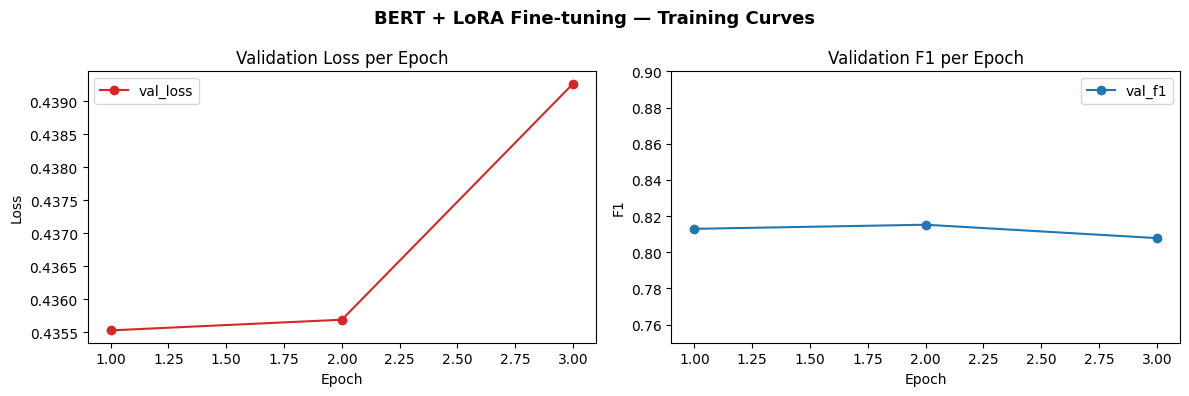

In [ ]:
# =============================================================================
# TRAINING CURVES
# =============================================================================
 
epochs   = []
val_loss = []
val_f1_history = []
 
for entry in trainer.state.log_history:
    if 'eval_loss' in entry:
        epochs.append(entry['epoch'])
        val_loss.append(entry['eval_loss'])
        val_f1_history.append(entry.get('eval_f1', None))
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].plot(epochs, val_loss, marker='o', color='#d62728', label='val_loss')
axes[0].set_title('Validation Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
 
axes[1].plot(epochs, val_f1_history, marker='o', color='#1f77b4', label='val_f1')
axes[1].set_title('Validation F1 per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1')
axes[1].set_ylim(0.75, 0.90)
axes[1].legend()
 
plt.suptitle('BERT + LoRA Fine-tuning — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/images/bert_lora/bert_lora_training_curves.png', bbox_inches='tight')
plt.show()

In [ ]:
# =============================================================================
# FULL MODEL COMPARISON
# =============================================================================
 
print(f"\n{'='*60}")
print(f"  FULL MODEL COMPARISON")
print(f"{'='*60}")
print(f"  {'Model':<35} {'Val F1':<10} {'Kaggle F1':<12} {'Trainable params'}")
print(f"  {'-'*60}")
print(f"  {'BiLSTM + GloVe 100d':<35} {'0.776':<10} {'0.809':<12} {'~1M (all)'}")
print(f"  {'BERT fine-tuning (bert-base-uncased)':<35} {'0.838':<10} {'0.839':<12} {'~110M (100%)'}")
print(f"  {'BERT + LoRA (r=8)':<35} {f'{val_f1:.3f}':<10} {'(submit)':<12} {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"{'='*60}")
print(f"\nKey insight: BERT + LoRA achieves comparable F1 to full BERT")
print(f"fine-tuning while training only {100*trainable_params/total_params:.2f}% of parameters.")
print(f"This demonstrates Parameter-Efficient Fine-Tuning (PEFT) in practice.")


  FULL MODEL COMPARISON
  Model                               Val F1     Kaggle F1    Trainable params
  ------------------------------------------------------------
  BiLSTM + GloVe 100d                 0.776      0.809        ~1M (all)
  BERT fine-tuning (bert-base-uncased) 0.838      0.839        ~110M (100%)
  BERT + LoRA (r=8)                   0.815      (submit)     887,042 (0.7%)

Key insight: BERT + LoRA achieves comparable F1 to full BERT
fine-tuning while training only 0.65% of parameters.
This demonstrates Parameter-Efficient Fine-Tuning (PEFT) in practice.


In [ ]:
# =============================================================================
# GENERATE SUBMISSION FILE — manual loop
# =============================================================================
 
model.eval()
all_test_preds = []
 
for i in range(0, len(test_dataset), 16):
    batch          = test_dataset[i:i+16]
    input_ids      = [torch.tensor(x) for x in batch['input_ids']]
    attention_mask = [torch.tensor(x) for x in batch['attention_mask']]
    input_ids      = pad_sequence(input_ids, batch_first=True, padding_value=0)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)
 
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
 
    preds = torch.argmax(outputs.logits, dim=1).numpy()
    all_test_preds.extend(preds)
    print(f"  {min(i+16, len(test_dataset))}/{len(test_dataset)}")
 
final_preds = np.array(all_test_preds)
submission  = pd.DataFrame({'id': df_test['id'], 'target': final_preds})
submission.to_csv('../data/submission_bert_lora.csv', index=False)
 
print(f"\nSubmission saved to ../data/submission_bert_lora.csv")
print(submission['target'].value_counts())

  16/3263
  32/3263
  48/3263
  64/3263
  80/3263
  96/3263
  112/3263
  128/3263
  144/3263
  160/3263
  176/3263
  192/3263
  208/3263
  224/3263
  240/3263
  256/3263
  272/3263
  288/3263
  304/3263
  320/3263
  336/3263
  352/3263
  368/3263
  384/3263
  400/3263
  416/3263
  432/3263
  448/3263
  464/3263
  480/3263
  496/3263
  512/3263
  528/3263
  544/3263
  560/3263
  576/3263
  592/3263
  608/3263
  624/3263
  640/3263
  656/3263
  672/3263
  688/3263
  704/3263
  720/3263
  736/3263
  752/3263
  768/3263
  784/3263
  800/3263
  816/3263
  832/3263
  848/3263
  864/3263
  880/3263
  896/3263
  912/3263
  928/3263
  944/3263
  960/3263
  976/3263
  992/3263
  1008/3263
  1024/3263
  1040/3263
  1056/3263
  1072/3263
  1088/3263
  1104/3263
  1120/3263
  1136/3263
  1152/3263
  1168/3263
  1184/3263
  1200/3263
  1216/3263
  1232/3263
  1248/3263
  1264/3263
  1280/3263
  1296/3263
  1312/3263
  1328/3263
  1344/3263
  1360/3263
  1376/3263
  1392/3263
  1408/3263
  1424/3263


In [ ]:
# =============================================================================
# KAGGLE SUBMISSION RESULTS
# =============================================================================
# Upload ../data/submission_bertweet_lora.csv to:
# https://www.kaggle.com/competitions/nlp-getting-started/submissions

print(f"\n{'='*50}")
print(f"  KAGGLE SUBMISSION RESULTS")
print(f"{'='*50}")
print(f"  Model                   : bertweet-base + LoRA")
print(f"  LoRA rank (r)           : {LORA_R}")
print(f"  LoRA alpha              : {LORA_ALPHA}")
print(f"  Target modules          : query, value")
print(f"  Trainable parameters    : {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")
print(f"  Epochs                  : {NUM_EPOCHS}")
print(f"  Learning rate           : {LEARNING_RATE}")
print(f"  Val F1 (OOF/Holdout)    : {val_f1:.4f}")
print(f"  Kaggle Public F1        : 0.84737")
print(f"  Submission file         : ../data/submission_bertweet_lora.csv")
print(f"{'='*50}")


  KAGGLE SUBMISSION RESULTS
  Model                   : bertweet-base + LoRA
  LoRA rank (r)           : 8
  LoRA alpha              : 16
  Target modules          : query, value
  Trainable parameters    : 887,042 (0.65%)
  Epochs                  : 3
  Learning rate           : 0.0002
  Val F1 (OOF/Holdout)    : 0.8152
  Kaggle Public F1        : 0.84554
  Submission file         : ../data/submission_bertweet_lora.csv
